In [ ]:
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import deque
import random
import math
import torch.nn.functional as F
from env.py import EcommerceEnv, train_df, val_df


=== Training vanilla DQN ===
Episode 50/1000 | Train Reward: -3.16 | Val Reward: 1.89
Episode 100/1000 | Train Reward: -2.29 | Val Reward: 0.50
Episode 150/1000 | Train Reward: -0.80 | Val Reward: 5.59
Episode 200/1000 | Train Reward: -1.68 | Val Reward: 3.74
Episode 250/1000 | Train Reward: -14.26 | Val Reward: 1.17
Episode 300/1000 | Train Reward: 25.35 | Val Reward: 1.55
Episode 350/1000 | Train Reward: -1.12 | Val Reward: 3.56
Episode 400/1000 | Train Reward: -0.99 | Val Reward: 4.38
Episode 450/1000 | Train Reward: 10.47 | Val Reward: 3.73
Episode 500/1000 | Train Reward: -1.02 | Val Reward: 3.18
Episode 550/1000 | Train Reward: -19.29 | Val Reward: -0.19
Episode 600/1000 | Train Reward: 4.46 | Val Reward: 5.31
Episode 650/1000 | Train Reward: -14.36 | Val Reward: 0.91
Episode 700/1000 | Train Reward: -4.96 | Val Reward: 0.84
Episode 750/1000 | Train Reward: -5.39 | Val Reward: 0.02
Episode 800/1000 | Train Reward: -7.80 | Val Reward: 0.78
Episode 850/1000 | Train Reward: -11.55 

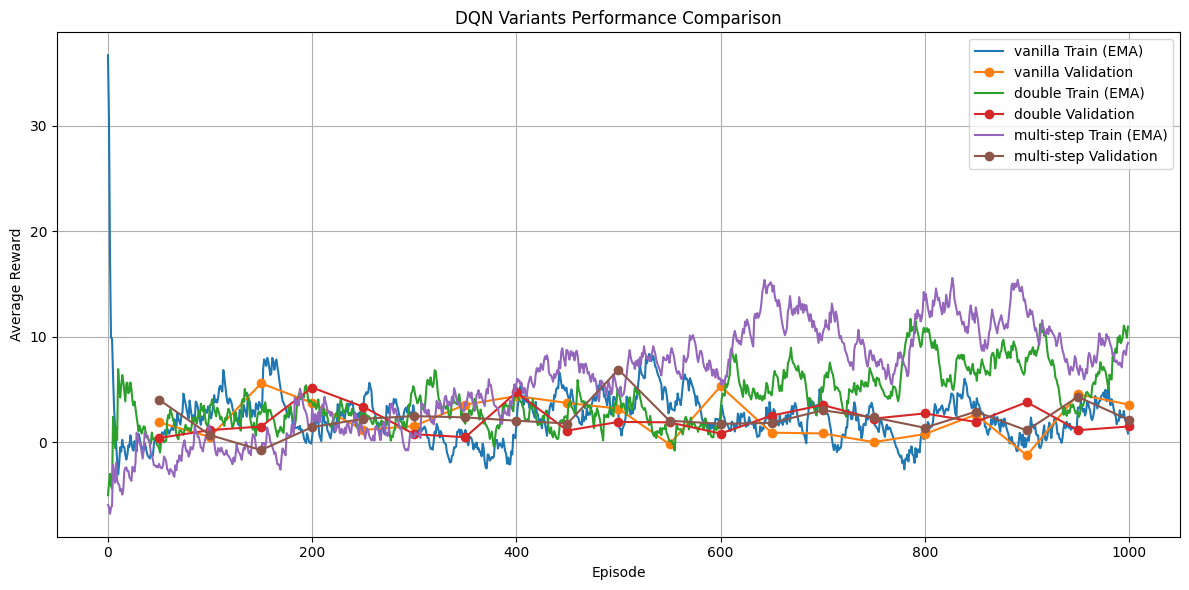

In [ ]:
# # ===== DQN Cell =====
# Device configuration
DEVICE = torch.device('cpu')

# Q-Network Architecture
class DQNBase(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=[128, 128]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        return self.net(x)

# Experience Replay (Supports Multi-Step Learning)
class ReplayBuffer:
    def __init__(self, capacity=50000, n_steps=1, gamma=0.99):
        self.buffer = deque(maxlen=capacity)
        self.n_steps = n_steps  # Multi-step learning parameter
        self.gamma = gamma      # Discount factor
        self.pending = deque(maxlen=n_steps)  # Temporarily stores incomplete multi-step trajectories

    def push(self, s, a, r, ns, d):
        """Store experience and automatically handle multi-step accumulation"""
        self.pending.append((s, a, r, ns, d))

        # Store when multi-step condition is met or when a terminal state is encountered
        if len(self.pending) >= self.n_steps or d:
            total_reward = 0
            for i in range(len(self.pending)):
                total_reward += self.pending[i][2] * (self.gamma ** i)

            final_state = self.pending[-1][3]
            final_done = self.pending[-1][4]
            self.buffer.append((
                self.pending[0][0],  # Initial state
                self.pending[0][1],  # Initial action
                total_reward,
                final_state,
                final_done
            ))

            if d:  # Terminal state requires resetting trajectory
                self.pending.clear()

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

# DQN Agent (Supports vanilla/double/multi-step)
class DQNAgent:
    def __init__(self, env, variant="vanilla",
                 hidden_dims=[128, 128], lr=1e-3, gamma=0.99,
                 eps_start=1.0, eps_end=0.01, eps_decay=5000,
                 buffer_size=50000, batch_size=128,
                 target_update=100, n_steps=1):
        self.env = env
        self.variant = variant
        self.gamma = gamma
        self.eps_params = (eps_start, eps_end, eps_decay)
        self.batch_size = batch_size
        self.target_update = target_update
        self.n_steps = n_steps if variant == "multi-step" else 1

        # Environment dimensions
        self.n_actions = env.action_space.n
        obs = env.reset()
        self.state_dim = len(self._flatten_obs(obs))

        # Network architecture
        self.policy_net = DQNBase(self.state_dim, self.n_actions, hidden_dims).to(DEVICE)
        self.target_net = DQNBase(self.state_dim, self.n_actions, hidden_dims).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Optimizer and buffer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size, n_steps=self.n_steps, gamma=gamma)
        self.steps_done = 0

    def _flatten_obs(self, obs):
        """Flatten observation data"""
        return np.concatenate([obs['user'], obs['history'], obs['context']]).astype(np.float32)

    def select_action(self, state, eval_mode=False):
        """ε-greedy policy"""
        eps_start, eps_end, eps_decay = self.eps_params
        eps = eps_end + (eps_start - eps_end) * math.exp(-1. * self.steps_done / eps_decay)

        if eval_mode or random.random() > eps:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
                q_values = self.policy_net(state_tensor)
                return q_values.argmax().item()
        else:
            return random.randrange(self.n_actions)

    def optimize_model(self):
        """Perform one step of optimization"""
        if len(self.memory) < self.batch_size:
            return

        # Sample a batch of data
        batch = self.memory.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to tensors
        states_tensor = torch.FloatTensor(np.stack(states)).to(DEVICE)
        actions_tensor = torch.LongTensor(actions).unsqueeze(1).to(DEVICE)
        rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1).to(DEVICE)
        next_states_tensor = torch.FloatTensor(np.stack(next_states)).to(DEVICE)
        dones_tensor = torch.FloatTensor(dones).unsqueeze(1).to(DEVICE)

        # Current Q-values
        current_q = self.policy_net(states_tensor).gather(1, actions_tensor)

        # Target Q-value calculation
        with torch.no_grad():
            if self.variant == "double":
                # Double DQN logic
                best_actions = self.policy_net(next_states_tensor).argmax(1, keepdim=True)
                next_q = self.target_net(next_states_tensor).gather(1, best_actions)
            else:
                # Vanilla DQN/Multi-Step DQN logic
                next_q = self.target_net(next_states_tensor).max(1, keepdim=True)[0]

            target_q = rewards_tensor + (self.gamma ** self.n_steps) * next_q * (1 - dones_tensor)

        # Compute loss
        loss = F.smooth_l1_loss(current_q, target_q)

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        # Update target network
        if self.steps_done % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        self.steps_done += 1

# Evaluation Function
def evaluate_agent(agent, env, n_episodes=20):
    total_reward = 0.0
    for _ in range(n_episodes):
        obs = env.reset()
        state = agent._flatten_obs(obs)
        done = False
        episode_reward = 0.0

        while not done:
            action = agent.select_action(state, eval_mode=True)
            next_obs, reward, done, _ = env.step(action)
            state = agent._flatten_obs(next_obs)
            episode_reward += reward

        total_reward += episode_reward

    return total_reward / n_episodes

# Training Loop
def train_and_plot(env_train, env_val, variants=["vanilla", "double", "multi-step"],
                   episodes=1000, eval_every=50):
    results = {}

    for variant in variants:
        print(f"\n=== Training {variant} DQN ===")

        # Initialize parameters
        n_steps = 3 if variant == "multi-step" else 1
        agent = DQNAgent(env_train, variant=variant, n_steps=n_steps)

        train_rewards = []
        val_rewards = []

        # Training loop
        for episode in range(1, episodes + 1):
            obs = env_train.reset()
            state = agent._flatten_obs(obs)
            done = False
            episode_reward = 0.0

            while not done:
                action = agent.select_action(state)
                next_obs, reward, done, _ = env_train.step(action)
                next_state = agent._flatten_obs(next_obs)

                # Store experience
                agent.memory.push(state, action, reward, next_state, done)

                # Optimize model
                agent.optimize_model()

                state = next_state
                episode_reward += reward

            train_rewards.append(episode_reward)

            # Periodic evaluation
            if episode % eval_every == 0:
                avg_val_reward = evaluate_agent(agent, env_val)
                val_rewards.append(avg_val_reward)
                print(f"Episode {episode}/{episodes} | "
                      f"Train Reward: {episode_reward:.2f} | "
                      f"Val Reward: {avg_val_reward:.2f}")

        results[variant] = (train_rewards, val_rewards)

    # Plot results
    plt.figure(figsize=(12, 6))
    for variant, (train, val) in results.items():
        # Training curve (EMA smoothing)
        ema_train = pd.Series(train).ewm(alpha=0.05).mean()
        plt.plot(ema_train, label=f"{variant} Train (EMA)")

        # Validation curve
        eval_x = np.arange(eval_every, episodes + 1, eval_every)
        plt.plot(eval_x, val, 'o-', label=f"{variant} Validation")

    plt.title("DQN Variants Performance Comparison")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Main Program
if __name__ == "__main__":
    # Assume environment and dataset are already prepared
    # from Env import EcommerceEnv

    # Create environments
    env_train = EcommerceEnv(train_df)
    env_val = EcommerceEnv(val_df)

    # Start training
    train_and_plot(
        env_train,
        env_val,
        variants=["vanilla", "double", "multi-step"],
        episodes=1000,
        eval_every=50
    )





